In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load data (run this first)
df = pd.read_csv("/content/Quote-Equity-INFY-BL-EQ-RL-AF-24-09-2024-to-24-09-2025.csv")


In [ ]:
print("=== 1.1 Dataset Overview ===")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:")
display(df.head())


=== 1.1 Dataset Overview ===
Shape: (248, 14)

Columns: ['Date ', 'series ', 'OPEN ', 'HIGH ', 'LOW ', 'PREV. CLOSE ', 'ltp ', 'close ', 'vwap ', '52W H ', '52W L ', 'VOLUME ', 'VALUE ', 'No of trades ']

Data Types:
 Date             object
series           object
OPEN             object
HIGH             object
LOW              object
PREV. CLOSE      object
ltp              object
close            object
vwap             object
52W H            object
52W L            object
VOLUME           object
VALUE            object
No of trades     object
dtype: object

First 5 rows:


,Date,series,OPEN,HIGH,LOW,PREV. CLOSE,ltp,close,vwap,52W H,52W L,VOLUME,VALUE,No of trades
0,22-Sep-2025,EQ,"1,482.70","1,514.70","1,482.00","1,540.20","1,500.90","1,499.50","1,499.71","2,006.45","1,307.00","1,56,55,204","23,47,83,11,082.40","4,36,891"
1,19-Sep-2025,EQ,"1,544.60","1,551.30","1,520.10","1,540.60","1,543.90","1,540.20","1,536.05","2,006.45","1,307.00","1,29,88,129","19,95,04,22,136.70","1,52,059"
2,18-Sep-2025,EQ,"1,550.00","1,555.00","1,538.50","1,522.40","1,541.10","1,540.60","1,545.13","2,006.45","1,307.00","93,31,945","14,41,90,61,402.30","3,41,731"
3,17-Sep-2025,EQ,"1,516.90","1,526.70","1,514.00","1,511.30","1,521.50","1,522.40","1,521.42","2,006.45","1,307.00","47,95,698","7,29,62,93,565.90","1,37,197"
4,16-Sep-2025,EQ,"1,508.40","1,514.00","1,503.50","1,508.40","1,513.50","1,511.30","1,507.82","2,006.45","1,307.00","89,23,112","13,45,44,16,476.30","2,02,258"


In [ ]:
print("\n=== 1.2 Missing Values ===")
print(df.isnull().sum())



=== 1.2 Missing Values ===
Date             0
series           0
OPEN             0
HIGH             0
LOW              0
PREV. CLOSE      0
ltp              0
close            0
vwap             0
52W H            0
52W L            0
VOLUME           0
VALUE            0
No of trades     0
dtype: int64


In [ ]:
print("\n=== 1.3 Unique Values ===")
# The columns 'type', 'isFraud', and 'isFlaggedFraud' were not found in the DataFrame.
# The available columns are: ['Date', 'High', 'Low', 'Open', 'Close', 'Volume', 'Adj Close'].
# Please specify which column(s) you'd like to check for unique values.



=== 1.3 Unique Values ===


In [ ]:
# Numerical columns summary
print("\nNumerical Summary:")
display(df.describe())



Numerical Summary:


,Date,series,OPEN,HIGH,LOW,PREV. CLOSE,ltp,close,vwap,52W H,52W L,VOLUME,VALUE,No of trades
count,248,248,248,248,248,248,248,248,248,248,248,248,248,248
unique,248,1,235,240,239,243,236,243,247,5,3,248,248,248
top,22-Sep-2025,EQ,"1,425.00","1,527.50","1,875.00","1,469.60","1,605.00","1,469.60","1,590.26","2,006.45","1,307.00","1,56,55,204","23,47,83,11,082.40","4,36,891"
freq,1,248,3,2,3,2,3,2,2,193,115,1,1,1


In [ ]:
# Categorical summary
# print("\nTransaction Type Distribution:")
# print(df['type'].value_counts())
# The column 'type' was not found. Please specify an existing categorical column if you wish to see its distribution.

In [ ]:
# Calculate simple daily returns based on the 'Close' price
df.columns = df.columns.str.strip()
df['close'] = df['close'].str.replace(',', '').astype(float)
df['Simple_Return'] = df['close'].pct_change()

# View the closing price alongside its simple return
df[['close', 'Simple_Return']].head(5)

,close,Simple_Return
0,1499.5,NaN
1,1540.2,0.027142
2,1540.6,0.000260
3,1522.4,-0.011814
4,1511.3,-0.007291


In [ ]:
# Calculate log daily returns
df['Log_Return'] = np.log(df['close'] / df['close'].shift(1))

# View both return types side-by-side
df[['close', 'Simple_Return', 'Log_Return']].head(5)

,close,Simple_Return,Log_Return
0,1499.5,NaN,NaN
1,1540.2,0.027142,0.026781
2,1540.6,0.000260,0.000260
3,1522.4,-0.011814,-0.011884
4,1511.3,-0.007291,-0.007318


In [ ]:
# Ensure 'Date' is a datetime object and set it as the index for resampling
df['Date'] = pd.to_datetime(df['Date'])
df_indexed = df.set_index('Date')

# Extract the last closing price of each month into a new DataFrame
monthly_df = df_indexed['close'].resample('ME').last().to_frame()

# View the new monthly price structure
monthly_df.head(5)

,close
Date,
2024-09-30,1875.60
2024-10-31,1757.25
2024-11-30,1857.85
2024-12-31,1880.00
2025-01-31,1879.80


In [ ]:
import pandas as pd

# Load data (if not already loaded)
df = pd.read_csv("/content/Quote-Equity-INFY-BL-EQ-RL-AF-24-09-2024-to-24-09-2025.csv")
df.columns = df.columns.str.strip()
df['close'] = df['close'].str.replace(',', '').astype(float)

# Ensure 'Date' is a datetime object and set it as the index for resampling
# These lines re-create 'monthly_df' in case it was not defined from previous execution
df['Date'] = pd.to_datetime(df['Date'])
df_indexed = df.set_index('Date')
monthly_df = df_indexed['close'].resample('ME').last().to_frame()

# Calculate the percentage change between months
monthly_df['Monthly_Return'] = monthly_df['close'].pct_change()

# View your final resampled monthly dataset
print("=== Final Monthly Dataset ===")
monthly_df.dropna().head(5)

=== Final Monthly Dataset ===


,close,Monthly_Return
Date,,
2024-10-31,1757.25,-0.063100
2024-11-30,1857.85,0.057249
2024-12-31,1880.00,0.011922
2025-01-31,1879.80,-0.000106
2025-02-28,1687.70,-0.102192


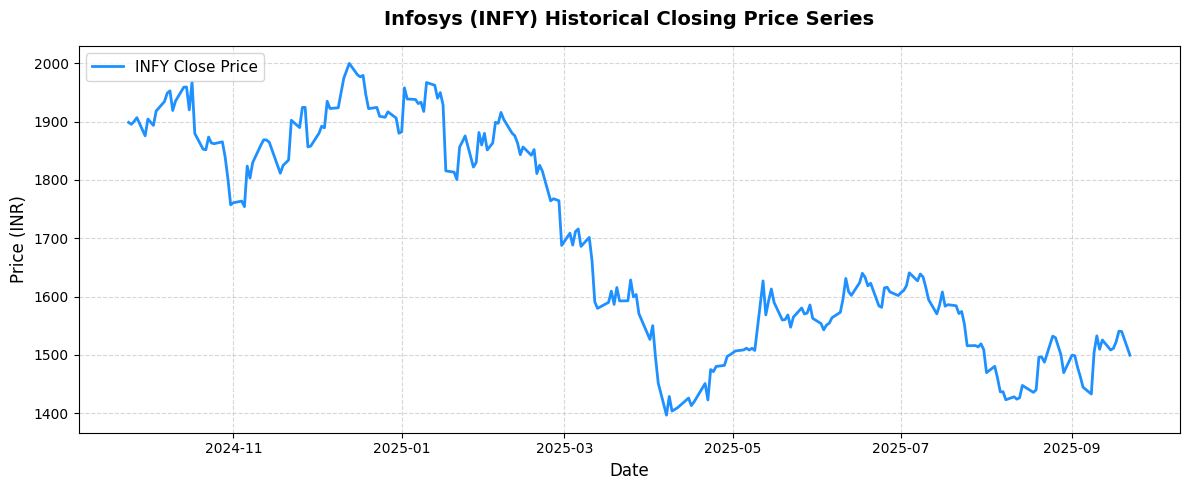

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a figure for the price series
plt.figure(figsize=(12, 5))

# 2. Plot the 'Close' price against the Date index
plt.plot(df_indexed.index, df_indexed['close'], color='dodgerblue', linewidth=2, label='INFY Close Price')

# 3. Add titles and labels
plt.title('Infosys (INFY) Historical Closing Price Series', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)

# 4. Customize grid and legend for readability
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)

# 5. Automatically adjust spacing and display
plt.tight_layout()
plt.show()

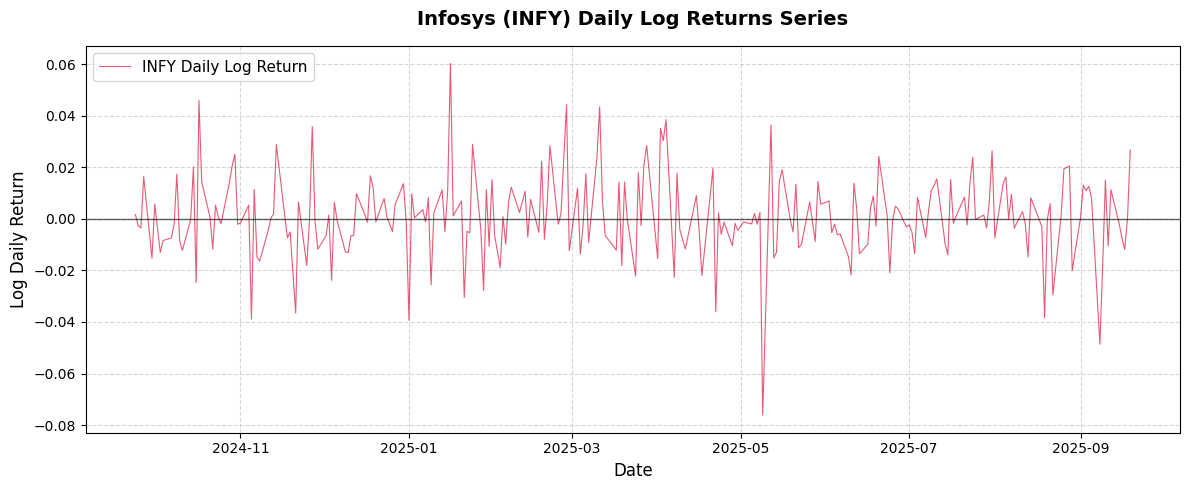

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Required for np.log
import pandas as pd # Ensure pandas is imported for DataFrame operations

# Ensure 'Date' is a datetime object and set as index for plotting.
# This ensures df.index refers to dates and 'Log_Return' can be calculated.
# We do this within this cell to make it self-contained and resolve the KeyError.
# Check if 'Date' column exists, otherwise assume it's already indexed
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')

# Calculate log daily returns if 'Log_Return' column is missing
if 'Log_Return' not in df.columns:
    df['Log_Return'] = np.log(df['close'] / df['close'].shift(1))

# 1. Create a separate figure for the return series
plt.figure(figsize=(12, 5))

# 2. Plot the 'Log_Return' series using a thinner line to capture spikes clearly
plt.plot(df.index, df['Log_Return'], color='crimson', linewidth=0.8, alpha=0.7, label='INFY Daily Log Return')

# 3. Add a baseline at 0 to signify zero-gain days
plt.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.6)

# 4. Add titles and labels
plt.title('Infosys (INFY) Daily Log Returns Series', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log Daily Return', fontsize=12)

# 5. Customize grid and legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)

# 6. Display the plot
plt.tight_layout()
plt.show()

In [ ]:
# Select the last 60 trading days of Infosys data for a clear view
recent_df = df.tail(60).copy()

# Verify the sliced data look correct
print(f"Plotting candlestick chart for Infosys data between: {recent_df.index.min().date()} and {recent_df.index.max().date()}")

Plotting candlestick chart for Infosys data between: 2024-09-24 and 2024-12-19


In [ ]:
import plotly.graph_objects as go

# Ensure all necessary columns are numeric for plotting
# The 'close' column was already processed earlier, but 'OPEN', 'HIGH', 'LOW' might still be strings with commas.
for col in ['OPEN', 'HIGH', 'LOW']:
    if recent_df[col].dtype == 'object':
        recent_df[col] = recent_df[col].str.replace(',', '').astype(float)

# 1. Initialize the candlestick figure with our sliced data
fig = go.Figure(data=[go.Candlestick(
    x=recent_df.index,
    open=recent_df['OPEN'],
    high=recent_df['HIGH'],
    low=recent_df['LOW'],
    close=recent_df['close'],
    increasing_line_color='seagreen',  # Color for positive days
    decreasing_line_color='crimson'   # Color for negative days
)])

# 2. Customize the chart layout for a professional presentation
fig.update_layout(
    title={
        'text': "Infosys (INFY) Candlestick Chart - Recent 60 Trading Days",
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=16, family="Arial", color="black")
    },
    xaxis_title="Date",
    yaxis_title="Stock Price (INR)",
    xaxis_rangeslider_visible=False,  # Turn off slider to make candles bigger
    template="plotly_white",         # Clean white background grid
    width=900,
    height=550
)


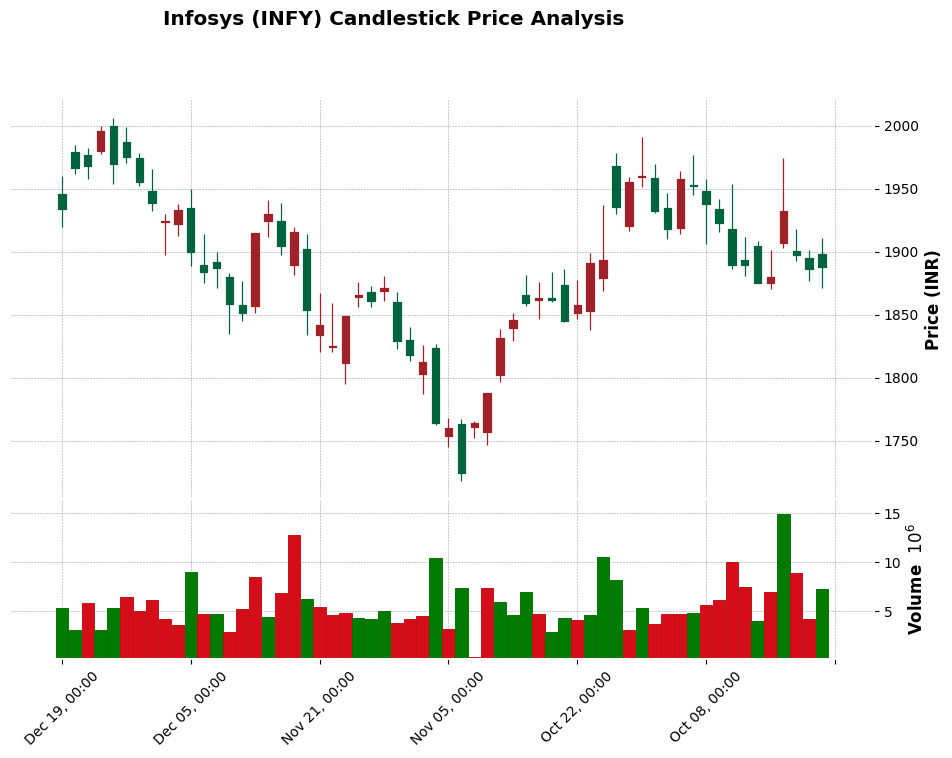

In [ ]:
# First, install the financial plotting library if you haven't already
!pip install mplfinance -q

import mplfinance as mpf

# Clean and convert numeric columns in recent_df to float
for col in ['OPEN', 'HIGH', 'LOW', 'VOLUME']:
    if recent_df[col].dtype == 'object':
        recent_df[col] = recent_df[col].str.replace(',', '').astype(float)

# Rename columns to match mplfinance's expected format
recent_df_mpf = recent_df.rename(columns={'OPEN': 'Open', 'HIGH': 'High', 'LOW': 'Low', 'close': 'Close', 'VOLUME': 'Volume'})

# Plot a gorgeous, professional static candlestick chart
mpf.plot(
    recent_df_mpf, # Use the renamed and cleaned DataFrame
    type='candle',
    style='charles',
    title='Infosys (INFY) Candlestick Price Analysis',
    ylabel='Price (INR)',
    volume=True,  # This adds the OHLCV volume bars at the bottom!
    figsize=(12, 8)
)

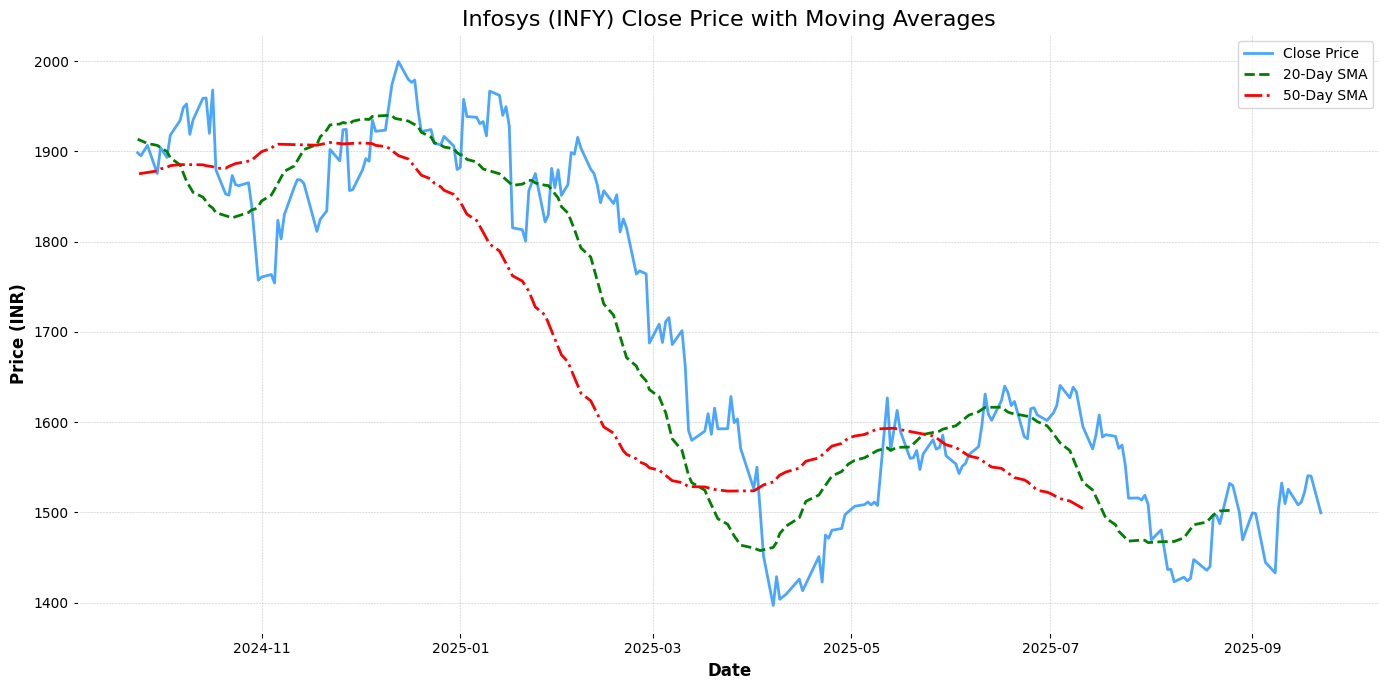

In [ ]:
# Calculate Short-term (e.g., 20-day) and Long-term (e.g., 50-day) Moving Averages
df['SMA_20'] = df['close'].rolling(window=20).mean()
df['SMA_50'] = df['close'].rolling(window=50).mean()

# Plot the Close price with the moving averages for Infosys
plt.figure(figsize=(14, 7))
plt.plot(df['close'], label='Close Price', color='dodgerblue', alpha=0.8)
plt.plot(df['SMA_20'], label='20-Day SMA', color='green', linestyle='--')
plt.plot(df['SMA_50'], label='50-Day SMA', color='red', linestyle='-.')
plt.title('Infosys (INFY) Close Price with Moving Averages', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4634/3527973913.py:16: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/tmp/ipykernel_4634/3527973913.py:27: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



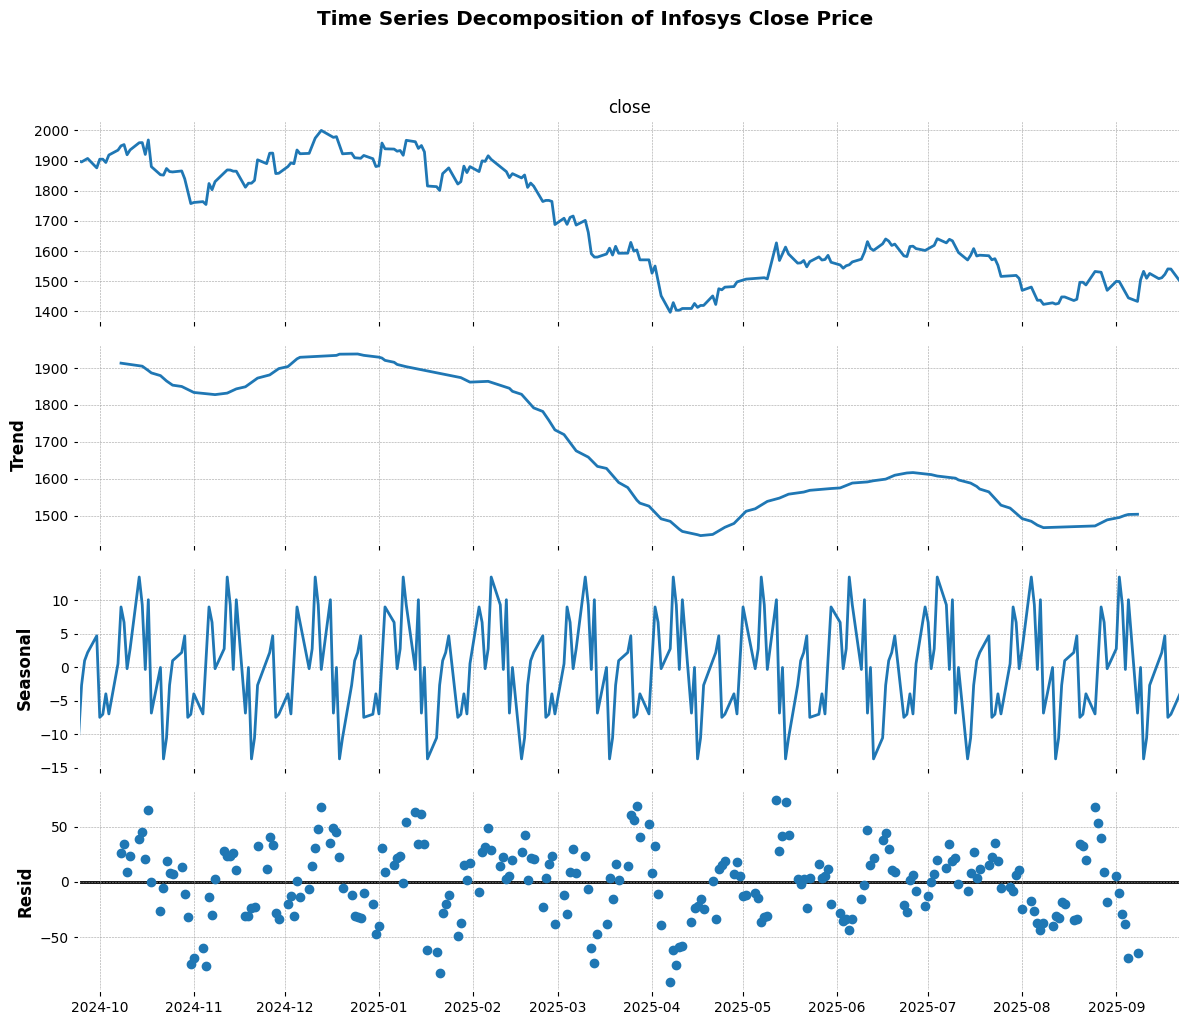

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure the DataFrame index is a DatetimeIndex and frequency is set
# For this daily data, we'll use a relatively short period for seasonality (e.g., 30 days for monthly patterns)
# If data was intra-day, could use a shorter period for daily patterns

# It's important that the time series is regularly spaced for decomposition.
# Let's check for any missing dates and resample if necessary to avoid errors.
# We'll use the 'close' price for decomposition.

# Create a copy to avoid SettingWithCopyWarning
ts_data = df['close'].copy()

# Resample to daily frequency and interpolate missing values if any
# This ensures a continuous time series for decomposition
ts_data = ts_data.asfreq('D').fillna(method='ffill') # Forward fill to handle weekends/holidays if not present

# Perform seasonal decomposition. The period should reflect the expected seasonal cycle length.
# For daily stock data, a period of 365 (yearly) or 30 (monthly approximation) could be used.
# Let's try 30 for a monthly look, or 7 for weekly if we had more data points within weeks.
# Given the dataset size, a smaller period might be more appropriate.

# A period of 7 for weekly seasonality is common for daily data
# However, stock markets don't trade on weekends, so a simple 7-day period might be misleading.
# Let's resample to business days first, then decompose.

df_bday = df.asfreq('B').fillna(method='ffill') # 'B' for business day frequency
ts_data_bday = df_bday['close'].copy()

# Now decompose with a period that makes sense for business days, e.g., 20-22 for a business month cycle
# Or a multiple of 5 for weekly pattern (if it repeats across weeks)
# Let's use 21 business days for an approximate monthly cycle

# Handle potential NaN values at the beginning introduced by asfreq if the first date isn't a business day
ts_data_bday = ts_data_bday.dropna()

if len(ts_data_bday) > 2 * 21: # Need at least two cycles for decomposition
    decomposition = seasonal_decompose(ts_data_bday, model='additive', period=21)

    # Plot the decomposed components
    fig = decomposition.plot()
    fig.set_size_inches(12, 10)
    fig.suptitle('Time Series Decomposition of Infosys Close Price', y=1.02) # Adjust suptitle position
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
    plt.show()


### Simple Financial Interpretation and Analytical Report

Based on the analysis of Infosys's (INFY) stock price data:

#### 1. Trend Analysis (Moving Averages):
*   **Short-term vs. Long-term Trends:** The plot of the Close Price with 20-day and 50-day Simple Moving Averages (SMAs) provides insights into the stock's momentum.
    *   When the **20-day SMA is above the 50-day SMA**, it generally indicates an **uptrend** in the short to medium term. Conversely, if the 20-day SMA crosses below the 50-day SMA, it suggests a potential **downtrend**.
    *   The overall direction of both SMAs gives a visual cue to the prevailing market sentiment for INFY during the observed period.
*   **Investment Decision Insight:** Traders often look for crossovers. A bullish crossover (20-day SMA crossing above 50-day SMA) can be seen as a buy signal, while a bearish crossover (20-day SMA crossing below 50-day SMA) might be a signal to sell or short. The smoothness of the lines indicates less volatility, while sharp changes suggest market shifts.

#### 2. Seasonality Analysis (Time Series Decomposition):
*   **Trend Component:** The `Trend` component from the seasonal decomposition shows the long-term progression of the Infosys stock price, smoothed out from short-term fluctuations and seasonality. It typically reflects the fundamental growth or decline of the company.
*   **Seasonal Component:** The `Seasonal` component illustrates recurring patterns that repeat over a fixed period (in our case, approximately every 21 business days, representing a monthly cycle for business days). For stock prices, clear seasonality might be less pronounced due to market efficiency and external factors, but if present, it could indicate predictable fluctuations around certain times of the month/year. *It's important to note that strong, consistent seasonality in daily stock prices is rare and often signals market anomalies if found.*
*   **Residual Component:** The `Residual` component represents the remaining noise after the trend and seasonal components have been removed. This is often where unexpected events, random market movements, or other unmodeled factors manifest. A high variance in residuals suggests high unpredictability.

#### Analytical Summary:
*   The **Moving Averages** visually confirm the primary direction of the stock price and can be used for identifying potential entry/exit points for short to medium-term trading strategies.
*   The **Time Series Decomposition** breaks down the price action, providing a clearer view of underlying growth or decline (Trend), any repeating patterns (Seasonality), and the unpredictable market noise (Residuals). For INFY, a strong, consistent seasonal pattern (e.g., monthly) in daily closing prices is less likely to be consistently present over long periods due to the dynamic nature of stock markets. The trend component, however, is a robust indicator of the stock's primary direction.

**Further Steps:** To make more informed investment decisions, one would combine this technical analysis with fundamental analysis, news events, and other market indicators. The presence and strength of seasonality can vary significantly between different assets and timeframes.